In [1]:
import pandas as pd

# fix order columns

In [ ]:
import re
import os
import pandas as pd

class QTRAP_Parse:
    def __init__(self, input_dir, output_dir):
        """
        Initialize the QTRAP_Parse class with input and output directories.

        Args:
            input_dir (str): Directory containing the input text files.
            output_dir (str): Directory to save the output CSV file.
        """
        self.input_dir = input_dir
        self.output_dir = output_dir
        self.output_file = os.path.join(self.output_dir, 'parsed_chromatogram_data.csv')

        # Initialize lists to store parsed data
        self.filenames = []
        self.q1_values = []
        self.q3_values = []
        self.lipids = []
        self.dates = []          # List for Date
        self.sample_names = []   # List for Sample_Name
        self.samples = []        # List for Sample
        self.summed_intensities = []  # List for Summed_Intensity
        self.tic_rsd_values = [] # List for TIC_RSD
        self.tic_summed_values = [] # List for TIC_Summed

        # Define lipid classes and their abbreviations
        self.lipid_classes = {
            'Phosphatidylcholine': 'PC',
            'Phosphatidylethanolamine': 'PE',
            'Phosphatidylserine': 'PS',
            'Phosphatidylinositol': 'PI',
            'Sphingomyelin': 'SM',
            'Ceramide': 'Cer',
            'Triglyceride': 'TG',
            'Diacylglycerol': 'DG',
            'Cholesterol Ester': 'CE',
            'Cardiolipin': 'CL',
            'Acyl Carnitine': 'Car',
            'Fatty Acid': 'FA'
        }

    def TIC_RSD(self, intensities):
        """
        Calculate the Relative Standard Deviation (RSD) for a given intensity array.

        Args:
            intensities (list of int): The intensity values.

        Returns:
            float: The RSD percentage rounded to two decimal places.
        """
        if not intensities:
            return 0.0
        mean = sum(intensities) / len(intensities)
        if mean == 0:
            return 0.0
        variance = sum((x - mean) ** 2 for x in intensities) / len(intensities)
        std_dev = variance ** 0.5
        rsd = (std_dev / mean) * 100
        return round(rsd, 2)

    def TIC_Summed(self, intensities):
        """
        Calculate the summed Total Ion Current (TIC) for a given intensity array.

        Args:
            intensities (list of int): The intensity values.

        Returns:
            int: The summed TIC.
        """
        return sum(intensities) if intensities else 0

    def parse_file(self, file_name):
        """
        Parse a single chromatogram text file to extract necessary data.

        Args:
            file_name (str): The name of the file to parse.
        """
        file_path = os.path.join(self.input_dir, file_name)

        # Extract Date and Sample_Name from the filename
        base_name = os.path.splitext(file_name)[0]  # Removes the .txt extension
        parts = base_name.split('_', 1)             # Split only on the first underscore
        if len(parts) == 2:
            date_str = parts[0]                     # e.g., '20241115'
            sample_name = parts[1]                  # e.g., 'Plasma_Acyl-Carnitines'
        else:
            # Handle unexpected filename formats
            date_str = ''
            sample_name = ''

        # Determine the Sample value based on Sample_Name
        sample = 'Blank' if 'Blank' in sample_name else 'Sample'

        # Open and read all lines of the file
        try:
            with open(file_path, 'r') as file:
                lines = file.readlines()
        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
            # Skip the file if it cannot be read
            return

        # -------------------
        # Extract TIC Data
        # -------------------
        TIC_intensities = []
        tic_found = False  # Flag to indicate if TIC section is found
        in_tic_section = False  # Flag to indicate parsing within TIC

        for i, line in enumerate(lines):
            if 'id: TIC' in line:
                tic_found = True
                in_tic_section = True
                continue  # Move to the next line

            if in_tic_section:
                # Look for 'cvParam: intensity array, number of detector counts'
                if 'cvParam: intensity array' in line:
                    # The intensity values are expected in the next line
                    if i + 1 < len(lines):
                        intensity_line = lines[i + 1].strip()
                        match = re.search(r'binary:\s+\[\d+\]\s+([\d\s]+)', intensity_line)
                        if match:
                            try:
                                TIC_intensities = list(map(int, match.group(1).split()))
                            except ValueError:
                                TIC_intensities = []
                        # Exit after finding the intensity array
                    break

        # Calculate TIC_RSD using the TIC_RSD function
        TIC_rsd = self.TIC_RSD(TIC_intensities)

        # Calculate TIC_Summed using the TIC_Summed function
        TIC_sum = self.TIC_Summed(TIC_intensities)

        # -------------------
        # Parse Lipid Data
        # -------------------
        current_filename = ""
        current_q1 = None
        current_q3 = None
        current_lipid = ""
        parsing_intensity = False
        intensities = []

        for line in lines:
            # Extract the filename (assumes filename appears earlier in the file)
            if 'sourceFile:' in line or 'name:' in line:
                match = re.search(r'name:\s+([\w.]+)', line)
                if match:
                    current_filename = match.group(1)

            # Extract Q1, Q3 values, and Lipid name
            if 'id: SRM SIC Q1=' in line:
                match = re.search(r'Q1=(\d+\.\d+).*Q3=(\d+\.\d+).*name=([^\s]+)', line)
                if match:
                    current_q1 = float(match.group(1))
                    current_q3 = float(match.group(2))
                    current_lipid = match.group(3)

            # Check if we are parsing intensity array data for lipids
            if 'cvParam: intensity array' in line:
                parsing_intensity = True
                intensities = []
            elif parsing_intensity and 'binary: [' in line:
                # Extract intensity values
                match = re.search(r'binary:\s+\[\d+\]\s+([\d\s]+)', line)
                if match:
                    try:
                        intensities = list(map(int, match.group(1).split()))
                        current_intensity_sum = sum(intensities)
                    except ValueError:
                        intensities = []
                        current_intensity_sum = 0

                    # Append the extracted and calculated data to the lists
                    if current_filename and current_q1 is not None and current_q3 is not None:
                        self.filenames.append(current_filename)
                        self.q1_values.append(current_q1)
                        self.q3_values.append(current_q3)
                        self.lipids.append(current_lipid)
                        self.dates.append(date_str)              # Append Date
                        self.sample_names.append(sample_name)    # Append Sample_Name
                        self.samples.append(sample)              # Append Sample
                        self.summed_intensities.append(current_intensity_sum)  # Append Summed_Intensity
                        self.tic_rsd_values.append(TIC_rsd)      # Append TIC_RSD
                        self.tic_summed_values.append(TIC_sum)   # Append TIC_Summed

                parsing_intensity = False

    def parse_all_files(self):
        """
        Iterate through all .txt files in the input directory and parse them.
        """
        if not os.path.isdir(self.input_dir):
            print(f"Input directory {self.input_dir} does not exist.")
            return

        # Ensure the output directory exists
        os.makedirs(self.output_dir, exist_ok=True)

        # Iterate through all .txt files in the specified directory
        for file_name in os.listdir(self.input_dir):
            if file_name.endswith('.txt'):
                self.parse_file(file_name)

    def generate_dataframe(self):
        """
        Generate a Pandas DataFrame from the parsed data.

        Returns:
            pd.DataFrame: DataFrame containing the parsed chromatogram data.
        """
        chromatogram_df = pd.DataFrame({
            'Date': self.dates,                        # Date column
            'Sample_Name': self.sample_names,          # Sample_Name column
            'Sample': self.samples,                    # Sample column
            'Lipid': self.lipids,
            'Q1': self.q1_values,
            'Q3': self.q3_values,
            'Summed_Intensity': self.summed_intensities,  # Summed_Intensity column
            'TIC_RSD': self.tic_rsd_values,            # TIC_RSD column
            'TIC_Summed': self.tic_summed_values,      # TIC_Summed column
            'Filename': self.filenames,
        })

        # Create Base_Sample_Name by removing 'Blank_' prefix if present
        chromatogram_df['Base_Sample_Name'] = chromatogram_df['Sample_Name'].str.replace('Blank_', '', regex=False)

        # Assign group numbers based on Base_Sample_Name
        chromatogram_df['Blank_Group'] = pd.factorize(chromatogram_df['Base_Sample_Name'])[0] + 1  # Start groups at 1

        # Drop the Base_Sample_Name column if not needed
        chromatogram_df.drop(columns=['Base_Sample_Name'], inplace=True)

        # Perform Blank Subtraction to create 'Intensity_Blank_Subtracted' column
        chromatogram_df = self.Blank_Subtract(chromatogram_df)

        # Assign Lipid Class Abbreviation using the updated Class function
        chromatogram_df = self.Class(chromatogram_df)

        # Normalize intensities within each Class for each Filename
        chromatogram_df = self.normalize_to_class(chromatogram_df)

        # Reorder columns for better readability as per user request
        columns_order = [
            'Lipid',
            'Q1',
            'Q3',
            'Summed_Intensity',
            'Intensity_Blank_Subtracted',
            'Normalized_Intensity',
            'TIC_RSD',
            'Class',
            'Sample_Name',
            'Blank_Group',
            # Include any additional columns if necessary
            'Date',
            'Sample',
            'TIC_Summed',
            'Filename'
        ]

        # Check if 'Normalized_Intensity' exists; if not, create it with default value 0
        if 'Normalized_Intensity' not in chromatogram_df.columns:
            chromatogram_df['Normalized_Intensity'] = 0

        # Reorder the columns
        chromatogram_df = chromatogram_df[columns_order]

        return chromatogram_df

    def Blank_Subtract(self, df):
        """
        Subtract the Summed_Intensity of blanks from samples within the same Blank_Group and Lipid.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Intensity_Blank_Subtracted' column.
        """
        # Create a DataFrame with blank intensities
        blanks = df[df['Sample'] == 'Blank'][['Blank_Group', 'Lipid', 'Summed_Intensity']].copy()
        blanks.rename(columns={'Summed_Intensity': 'Blank_Summed_Intensity'}, inplace=True)

        # Merge the blank intensities with the original DataFrame on Blank_Group and Lipid
        df = df.merge(blanks, on=['Blank_Group', 'Lipid'], how='left')

        # Define a function to subtract blank intensity from sample intensity
        def subtract_blank(row):
            if row['Sample'] == 'Sample' and not pd.isna(row['Blank_Summed_Intensity']):
                subtracted = row['Summed_Intensity'] - row['Blank_Summed_Intensity']
                return subtracted if subtracted > 0 else 0
            else:
                return 0  # For blanks or if no corresponding blank found

        # Apply the subtraction
        df['Intensity_Blank_Subtracted'] = df.apply(subtract_blank, axis=1)

        # Drop the 'Blank_Summed_Intensity' column as it's no longer needed
        df.drop(columns=['Blank_Summed_Intensity'], inplace=True)

        return df
    
    def Class(self, df):
        """
        Assign the Lipid Class Abbreviation based on values from class_order and class_abbreviation_mapping.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Class' column.
        """
        # Define the class order with 'Unknown' prioritized last
        class_order = [
            'CAR',  # Acyl-Carnitines
            'Cer',  # Ceramides
            'CE',   # Cholesteryl Esters
            'DG',   # DG
            'FA',   # FFA (Fatty Acids)
            'PC',   # PC
            'PE',   # PE
            'PG',   # PG
            'PI',   # PI
            'PS',   # PS
            'SM',   # SM
            'TG'    # TG
        ]

        # Define the mapping from full class names to abbreviations
        class_abbreviation_mapping = {
            'Acyl-Carnitines': 'CAR',
            'Ceramides': 'Cer',
            'Cholesteryl Esters': 'CE',
            'DG': 'DG',
            'FFA': 'FA',
            'PC': 'PC',
            'PE': 'PE',
            'PG': 'PG',
            'PI': 'PI',
            'PS': 'PS',
            'SM': 'SM',
            'TG': 'TG',
            'Unknown': 'Unknown'  # To handle unknown classes
        }

        def find_class(sample_name):
            # Check for direct match with class abbreviations
            for class_abbr in class_order:
                if re.search(rf'\b{re.escape(class_abbr)}\b', sample_name):
                    return class_abbr

            # Check for substring match with full class names (case-insensitive)
            for full_name, abbr in class_abbreviation_mapping.items():
                if re.search(rf'{re.escape(full_name)}', sample_name, re.IGNORECASE):
                    return abbr

            return 'Unknown'

        # Apply the matching function to the Sample_Name column
        df['Class'] = df['Sample_Name'].apply(find_class)

        return df

    def normalize_to_class(self, df):
        """
        Normalize the 'Intensity_Blank_Subtracted' values to the highest value in each Class for each Filename.
        The highest value in each group is set to 1, and others are scaled accordingly.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Normalized_Intensity' column.
        """
        # Using transform with lambda for efficiency
        df['Normalized_Intensity'] = df.groupby(['Filename', 'Class'])['Intensity_Blank_Subtracted'].transform(
            lambda x: x / x.max() if x.max() > 0 else 0
        )
        return df

    def save_to_csv(self, dataframe):
        """
        Save the DataFrame to a CSV file.

        Args:
            dataframe (pd.DataFrame): The DataFrame to save.
        """
        try:
            dataframe.to_csv(self.output_file, index=False)
            print(f"Data successfully saved to {self.output_file}")
        except Exception as e:
            # Handle exceptions by printing the error
            print(f"Error saving CSV: {e}")

    def run(self):
        """
        Execute the parsing process: parse all files, generate DataFrame, and save to CSV.

        Returns:
            pd.DataFrame: The resulting DataFrame after parsing.
        """
        self.parse_all_files()
        df = self.generate_dataframe()
        self.save_to_csv(df)
        return df


# working above try new version

# fix class for TG

In [ ]:
import re
import os
import pandas as pd

class QTRAP_Parse:
    def __init__(self, input_dir, output_dir):
        """
        Initialize the QTRAP_Parse class with input and output directories.

        Args:
            input_dir (str): Directory containing the input text files.
            output_dir (str): Directory to save the output CSV file.
        """
        self.input_dir = input_dir
        self.output_dir = output_dir
        self.output_file = os.path.join(self.output_dir, 'parsed_chromatogram_data.csv')

        # Initialize lists to store parsed data
        self.filenames = []
        self.q1_values = []
        self.q3_values = []
        self.lipids = []
        self.dates = []          # List for Date
        self.sample_names = []   # List for Sample_Name
        self.samples = []        # List for Sample
        self.summed_intensities = []  # List for Summed_Intensity
        self.tic_rsd_values = [] # List for TIC_RSD
        self.tic_summed_values = [] # List for TIC_Summed

        # Define lipid classes and their abbreviations
        self.lipid_classes = {
            'Phosphatidylcholine': 'PC',
            'Phosphatidylethanolamine': 'PE',
            'Phosphatidylserine': 'PS',
            'Phosphatidylinositol': 'PI',
            'Sphingomyelin': 'SM',
            'Ceramide': 'Cer',
            'Triglyceride': 'TG',
            'Diacylglycerol': 'DG',
            'Cholesterol Ester': 'CE',
            'Cardiolipin': 'CL',
            'Acyl Carnitine': 'Car',
            'Fatty Acid': 'FA'
        }

    def TIC_RSD(self, intensities):
        """
        Calculate the Relative Standard Deviation (RSD) for a given intensity array.

        Args:
            intensities (list of int): The intensity values.

        Returns:
            float: The RSD percentage rounded to two decimal places.
        """
        if not intensities:
            return 0.0
        mean = sum(intensities) / len(intensities)
        if mean == 0:
            return 0.0
        variance = sum((x - mean) ** 2 for x in intensities) / len(intensities)
        std_dev = variance ** 0.5
        rsd = (std_dev / mean) * 100
        return round(rsd, 2)

    def TIC_Summed(self, intensities):
        """
        Calculate the summed Total Ion Current (TIC) for a given intensity array.

        Args:
            intensities (list of int): The intensity values.

        Returns:
            int: The summed TIC.
        """
        return sum(intensities) if intensities else 0

    def parse_file(self, file_name):
        """
        Parse a single chromatogram text file to extract necessary data.

        Args:
            file_name (str): The name of the file to parse.
        """
        file_path = os.path.join(self.input_dir, file_name)

        # Extract Date and Sample_Name from the filename
        base_name = os.path.splitext(file_name)[0]  # Removes the .txt extension
        parts = base_name.split('_', 1)             # Split only on the first underscore
        if len(parts) == 2:
            date_str = parts[0]                     # e.g., '20241115'
            sample_name = parts[1]                  # e.g., 'Plasma_Acyl-Carnitines'
        else:
            # Handle unexpected filename formats
            date_str = ''
            sample_name = ''

        # Determine the Sample value based on Sample_Name
        sample = 'Blank' if 'Blank' in sample_name else 'Sample'

        # Open and read all lines of the file
        try:
            with open(file_path, 'r') as file:
                lines = file.readlines()
        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
            # Skip the file if it cannot be read
            return

        # -------------------
        # Extract TIC Data
        # -------------------
        TIC_intensities = []
        tic_found = False  # Flag to indicate if TIC section is found
        in_tic_section = False  # Flag to indicate parsing within TIC

        for i, line in enumerate(lines):
            if 'id: TIC' in line:
                tic_found = True
                in_tic_section = True
                continue  # Move to the next line

            if in_tic_section:
                # Look for 'cvParam: intensity array, number of detector counts'
                if 'cvParam: intensity array' in line:
                    # The intensity values are expected in the next line
                    if i + 1 < len(lines):
                        intensity_line = lines[i + 1].strip()
                        match = re.search(r'binary:\s+\[\d+\]\s+([\d\s]+)', intensity_line)
                        if match:
                            try:
                                TIC_intensities = list(map(int, match.group(1).split()))
                            except ValueError:
                                TIC_intensities = []
                        # Exit after finding the intensity array
                    break

        # Calculate TIC_RSD using the TIC_RSD function
        TIC_rsd = self.TIC_RSD(TIC_intensities)

        # Calculate TIC_Summed using the TIC_Summed function
        TIC_sum = self.TIC_Summed(TIC_intensities)

        # -------------------
        # Parse Lipid Data
        # -------------------
        current_filename = ""
        current_q1 = None
        current_q3 = None
        current_lipid = ""
        parsing_intensity = False
        intensities = []

        for line in lines:
            # Extract the filename (assumes filename appears earlier in the file)
            if 'sourceFile:' in line or 'name:' in line:
                match = re.search(r'name:\s+([\w.]+)', line)
                if match:
                    current_filename = match.group(1)

            # Extract Q1, Q3 values, and Lipid name
            if 'id: SRM SIC Q1=' in line:
                match = re.search(r'Q1=(\d+\.\d+).*Q3=(\d+\.\d+).*name=([^\s]+)', line)
                if match:
                    current_q1 = float(match.group(1))
                    current_q3 = float(match.group(2))
                    current_lipid = match.group(3)

            # Check if we are parsing intensity array data for lipids
            if 'cvParam: intensity array' in line:
                parsing_intensity = True
                intensities = []
            elif parsing_intensity and 'binary: [' in line:
                # Extract intensity values
                match = re.search(r'binary:\s+\[\d+\]\s+([\d\s]+)', line)
                if match:
                    try:
                        intensities = list(map(int, match.group(1).split()))
                        current_intensity_sum = sum(intensities)
                    except ValueError:
                        intensities = []
                        current_intensity_sum = 0

                    # Append the extracted and calculated data to the lists
                    if current_filename and current_q1 is not None and current_q3 is not None:
                        self.filenames.append(current_filename)
                        self.q1_values.append(current_q1)
                        self.q3_values.append(current_q3)
                        self.lipids.append(current_lipid)
                        self.dates.append(date_str)              # Append Date
                        self.sample_names.append(sample_name)    # Append Sample_Name
                        self.samples.append(sample)              # Append Sample
                        self.summed_intensities.append(current_intensity_sum)  # Append Summed_Intensity
                        self.tic_rsd_values.append(TIC_rsd)      # Append TIC_RSD
                        self.tic_summed_values.append(TIC_sum)   # Append TIC_Summed

                parsing_intensity = False

    def parse_all_files(self):
        """
        Iterate through all .txt files in the input directory and parse them.
        """
        if not os.path.isdir(self.input_dir):
            print(f"Input directory {self.input_dir} does not exist.")
            return

        # Ensure the output directory exists
        os.makedirs(self.output_dir, exist_ok=True)

        # Iterate through all .txt files in the specified directory
        for file_name in os.listdir(self.input_dir):
            if file_name.endswith('.txt'):
                self.parse_file(file_name)

    def generate_dataframe(self):
        """
        Generate a Pandas DataFrame from the parsed data.

        Returns:
            pd.DataFrame: DataFrame containing the parsed chromatogram data.
        """
        chromatogram_df = pd.DataFrame({
            'Date': self.dates,                        # Date column
            'Sample_Name': self.sample_names,          # Sample_Name column
            'Sample': self.samples,                    # Sample column
            'Lipid': self.lipids,
            'Q1': self.q1_values,
            'Q3': self.q3_values,
            'Summed_Intensity': self.summed_intensities,  # Summed_Intensity column
            'TIC_RSD': self.tic_rsd_values,            # TIC_RSD column
            'TIC_Summed': self.tic_summed_values,      # TIC_Summed column
            'Filename': self.filenames,
        })

        # Create Base_Sample_Name by removing 'Blank_' prefix if present
        chromatogram_df['Base_Sample_Name'] = chromatogram_df['Sample_Name'].str.replace('Blank_', '', regex=False)

        # Assign group numbers based on Base_Sample_Name
        chromatogram_df['Blank_Group'] = pd.factorize(chromatogram_df['Base_Sample_Name'])[0] + 1  # Start groups at 1

        # Drop the Base_Sample_Name column if not needed
        chromatogram_df.drop(columns=['Base_Sample_Name'], inplace=True)

        # Perform Blank Subtraction to create 'Intensity_Blank_Subtracted' column
        chromatogram_df = self.Blank_Subtract(chromatogram_df)

        # Assign Lipid Class Abbreviation using the updated Class function
        chromatogram_df = self.Class(chromatogram_df)

        # Normalize intensities within each Class for each Filename
        chromatogram_df = self.normalize_to_class(chromatogram_df)

        # Reorder columns for better readability as per user request
        columns_order = [
            'Lipid',
            'Q1',
            'Q3',
            'Summed_Intensity',
            'Intensity_Blank_Subtracted',
            'Normalized_Intensity',
            'TIC_RSD',
            'Class',
            'Sample_Name',
            'Blank_Group',
            # Include any additional columns if necessary
            'Date',
            'Sample',
            'TIC_Summed',
            'Filename'
        ]

        # Check if 'Normalized_Intensity' exists; if not, create it with default value 0
        if 'Normalized_Intensity' not in chromatogram_df.columns:
            chromatogram_df['Normalized_Intensity'] = 0

        # Reorder the columns
        chromatogram_df = chromatogram_df[columns_order]

        return chromatogram_df

    def Blank_Subtract(self, df):
        """
        Subtract the Summed_Intensity of blanks from samples within the same Blank_Group and Lipid.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Intensity_Blank_Subtracted' column.
        """
        # Create a DataFrame with blank intensities
        blanks = df[df['Sample'] == 'Blank'][['Blank_Group', 'Lipid', 'Summed_Intensity']].copy()
        blanks.rename(columns={'Summed_Intensity': 'Blank_Summed_Intensity'}, inplace=True)

        # Merge the blank intensities with the original DataFrame on Blank_Group and Lipid
        df = df.merge(blanks, on=['Blank_Group', 'Lipid'], how='left')

        # Define a function to subtract blank intensity from sample intensity
        def subtract_blank(row):
            if row['Sample'] == 'Sample' and not pd.isna(row['Blank_Summed_Intensity']):
                subtracted = row['Summed_Intensity'] - row['Blank_Summed_Intensity']
                return subtracted if subtracted > 0 else 0
            else:
                return 0  # For blanks or if no corresponding blank found

        # Apply the subtraction
        df['Intensity_Blank_Subtracted'] = df.apply(subtract_blank, axis=1)

        # Drop the 'Blank_Summed_Intensity' column as it's no longer needed
        df.drop(columns=['Blank_Summed_Intensity'], inplace=True)

        return df


    def Class(self, df):
        """
        Assign the Lipid Class Abbreviation based on values from class_order and class_abbreviation_mapping.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Class' column.
        """
        # Define the class order with 'Unknown' prioritized last
        class_order = [
            'CAR',  # Acyl-Carnitines
            'Cer',  # Ceramides
            'CE',   # Cholesteryl Esters
            'DG',   # DG
            'FA',   # FFA (Fatty Acids)
            'PC',   # PC
            'PE',   # PE
            'PG',   # PG
            'PI',   # PI
            'PS',   # PS
            'SM',   # SM
            'TG'    # TG
        ]

        # Define the mapping from full class names to abbreviations
        class_abbreviation_mapping = {
            'Acyl-Carnitines': 'CAR',
            'Ceramides': 'Cer',
            'Cholesteryl Esters': 'CE',
            'DG': 'DG',
            'FFA': 'FA',
            'PC': 'PC',
            'PE': 'PE',
            'PG': 'PG',
            'PI': 'PI',
            'PS': 'PS',
            'SM': 'SM',
            'TG': 'TG',
            'Unknown': 'Unknown'  # To handle unknown classes
        }

        def find_class(sample_name):
            """
            Determine the lipid class abbreviation based on the sample name.

            Args:
                sample_name (str): The name of the sample.

            Returns:
                str: The lipid class abbreviation or 'Unknown' if no match is found.
            """
            # Step 1: Remove everything up to and including the first underscore
            # Example: 'Plasma_Ceramide_123' -> 'Ceramide_123'
            parts = sample_name.split('_', 1)
            if len(parts) > 1:
                relevant_part = parts[1]
            else:
                relevant_part = sample_name  # If no underscore is present

            # Step 2: Specifically remove the 'Plasma_' prefix if present
            # This handles cases where there might be multiple underscores
            if relevant_part.startswith('Plasma_'):
                relevant_part = relevant_part[len('Plasma_'):]

            # Debugging: Uncomment the following line to see the extracted relevant_part
            # print(f"Processing Sample_Name: '{sample_name}' -> Relevant Part: '{relevant_part}'")

            # Step 3: Check for direct match with class abbreviations
            for class_abbr in class_order:
                if re.search(rf'\b{re.escape(class_abbr)}\b', relevant_part):
                    return class_abbr

            # Step 4: Check for substring match with full class names (case-insensitive)
            for full_name, abbr in class_abbreviation_mapping.items():
                if re.search(rf'{re.escape(full_name)}', relevant_part, re.IGNORECASE):
                    return abbr

            # Step 5: If no match is found, return 'Unknown'
            return 'Unknown'

        # Apply the matching function to the Sample_Name column
        df['Class'] = df['Sample_Name'].apply(find_class)

        return df


    def normalize_to_class(self, df):
        """
        Normalize the 'Intensity_Blank_Subtracted' values to the highest value in each Class for each Filename.
        The highest value in each group is set to 1, and others are scaled accordingly.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Normalized_Intensity' column.
        """
        # Using transform with lambda for efficiency
        df['Normalized_Intensity'] = df.groupby(['Filename', 'Class'])['Intensity_Blank_Subtracted'].transform(
            lambda x: x / x.max() if x.max() > 0 else 0
        )
        return df

    def save_to_csv(self, dataframe):
        """
        Save the DataFrame to a CSV file.

        Args:
            dataframe (pd.DataFrame): The DataFrame to save.
        """
        try:
            dataframe.to_csv(self.output_file, index=False)
            print(f"Data successfully saved to {self.output_file}")
        except Exception as e:
            # Handle exceptions by printing the error
            print(f"Error saving CSV: {e}")

    def run(self):
        """
        Execute the parsing process: parse all files, generate DataFrame, and save to CSV.

        Returns:
            pd.DataFrame: The resulting DataFrame after parsing.
        """
        self.parse_all_files()
        df = self.generate_dataframe()
        self.save_to_csv(df)
        return df


# Update to normalize based off class not sample

In [2]:
import re
import os
import pandas as pd

class QTRAP_Parse:
    def __init__(self, input_dir, output_dir):
        """
        Initialize the QTRAP_Parse class with input and output directories.

        Args:
            input_dir (str): Directory containing the input text files.
            output_dir (str): Directory to save the output CSV file.
        """
        self.input_dir = input_dir
        self.output_dir = output_dir
        self.output_file = os.path.join(self.output_dir, 'parsed_chromatogram_data.csv')

        # Initialize lists to store parsed data
        self.filenames = []
        self.q1_values = []
        self.q3_values = []
        self.lipids = []
        self.dates = []          # List for Date
        self.sample_names = []   # List for Sample_Name
        self.samples = []        # List for Sample
        self.summed_intensities = []  # List for Summed_Intensity
        self.tic_rsd_values = [] # List for TIC_RSD
        self.tic_summed_values = [] # List for TIC_Summed

        # Define lipid classes and their abbreviations
        self.lipid_classes = {
            'Phosphatidylcholine': 'PC',
            'Phosphatidylethanolamine': 'PE',
            'Phosphatidylserine': 'PS',
            'Phosphatidylinositol': 'PI',
            'Sphingomyelin': 'SM',
            'Ceramide': 'Cer',
            'Triglyceride': 'TG',
            'Diacylglycerol': 'DG',
            'Cholesterol Ester': 'CE',
            'Cardiolipin': 'CL',
            'Acyl Carnitine': 'Car',
            'Fatty Acid': 'FA'
        }

    def TIC_RSD(self, intensities):
        """
        Calculate the Relative Standard Deviation (RSD) for a given intensity array.

        Args:
            intensities (list of int): The intensity values.

        Returns:
            float: The RSD percentage rounded to two decimal places.
        """
        if not intensities:
            return 0.0
        mean = sum(intensities) / len(intensities)
        if mean == 0:
            return 0.0
        variance = sum((x - mean) ** 2 for x in intensities) / len(intensities)
        std_dev = variance ** 0.5
        rsd = (std_dev / mean) * 100
        return round(rsd, 2)

    def TIC_Summed(self, intensities):
        """
        Calculate the summed Total Ion Current (TIC) for a given intensity array.

        Args:
            intensities (list of int): The intensity values.

        Returns:
            int: The summed TIC.
        """
        return sum(intensities) if intensities else 0

    def parse_file(self, file_name):
        """
        Parse a single chromatogram text file to extract necessary data.

        Args:
            file_name (str): The name of the file to parse.
        """
        file_path = os.path.join(self.input_dir, file_name)

        # Extract Date and Sample_Name from the filename
        base_name = os.path.splitext(file_name)[0]  # Removes the .txt extension
        parts = base_name.split('_', 1)             # Split only on the first underscore
        if len(parts) == 2:
            date_str = parts[0]                     # e.g., '20241115'
            sample_name = parts[1]                  # e.g., 'Plasma_Acyl-Carnitines'
        else:
            # Handle unexpected filename formats
            date_str = ''
            sample_name = ''

        # Determine the Sample value based on Sample_Name
        sample = 'Blank' if 'Blank' in sample_name else 'Sample'

        # Open and read all lines of the file
        try:
            with open(file_path, 'r') as file:
                lines = file.readlines()
        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
            # Skip the file if it cannot be read
            return

        # -------------------
        # Extract TIC Data
        # -------------------
        TIC_intensities = []
        tic_found = False  # Flag to indicate if TIC section is found
        in_tic_section = False  # Flag to indicate parsing within TIC

        for i, line in enumerate(lines):
            if 'id: TIC' in line:
                tic_found = True
                in_tic_section = True
                continue  # Move to the next line

            if in_tic_section:
                # Look for 'cvParam: intensity array, number of detector counts'
                if 'cvParam: intensity array' in line:
                    # The intensity values are expected in the next line
                    if i + 1 < len(lines):
                        intensity_line = lines[i + 1].strip()
                        match = re.search(r'binary:\s+\[\d+\]\s+([\d\s]+)', intensity_line)
                        if match:
                            try:
                                TIC_intensities = list(map(int, match.group(1).split()))
                            except ValueError:
                                TIC_intensities = []
                        # Exit after finding the intensity array
                    break

        # Calculate TIC_RSD using the TIC_RSD function
        TIC_rsd = self.TIC_RSD(TIC_intensities)

        # Calculate TIC_Summed using the TIC_Summed function
        TIC_sum = self.TIC_Summed(TIC_intensities)

        # -------------------
        # Parse Lipid Data
        # -------------------
        current_filename = ""
        current_q1 = None
        current_q3 = None
        current_lipid = ""
        parsing_intensity = False
        intensities = []

        for line in lines:
            # Extract the filename (assumes filename appears earlier in the file)
            if 'sourceFile:' in line or 'name:' in line:
                match = re.search(r'name:\s+([\w.]+)', line)
                if match:
                    current_filename = match.group(1)

            # Extract Q1, Q3 values, and Lipid name
            if 'id: SRM SIC Q1=' in line:
                match = re.search(r'Q1=(\d+\.\d+).*Q3=(\d+\.\d+).*name=([^\s]+)', line)
                if match:
                    current_q1 = float(match.group(1))
                    current_q3 = float(match.group(2))
                    current_lipid = match.group(3)

            # Check if we are parsing intensity array data for lipids
            if 'cvParam: intensity array' in line:
                parsing_intensity = True
                intensities = []
            elif parsing_intensity and 'binary: [' in line:
                # Extract intensity values
                match = re.search(r'binary:\s+\[\d+\]\s+([\d\s]+)', line)
                if match:
                    try:
                        intensities = list(map(int, match.group(1).split()))
                        current_intensity_sum = sum(intensities)
                    except ValueError:
                        intensities = []
                        current_intensity_sum = 0

                    # Append the extracted and calculated data to the lists
                    if current_filename and current_q1 is not None and current_q3 is not None:
                        self.filenames.append(current_filename)
                        self.q1_values.append(current_q1)
                        self.q3_values.append(current_q3)
                        self.lipids.append(current_lipid)
                        self.dates.append(date_str)              # Append Date
                        self.sample_names.append(sample_name)    # Append Sample_Name
                        self.samples.append(sample)              # Append Sample
                        self.summed_intensities.append(current_intensity_sum)  # Append Summed_Intensity
                        self.tic_rsd_values.append(TIC_rsd)      # Append TIC_RSD
                        self.tic_summed_values.append(TIC_sum)   # Append TIC_Summed

                parsing_intensity = False

    def parse_all_files(self):
        """
        Iterate through all .txt files in the input directory and parse them.
        """
        if not os.path.isdir(self.input_dir):
            print(f"Input directory {self.input_dir} does not exist.")
            return

        # Ensure the output directory exists
        os.makedirs(self.output_dir, exist_ok=True)

        # Iterate through all .txt files in the specified directory
        for file_name in os.listdir(self.input_dir):
            if file_name.endswith('.txt'):
                self.parse_file(file_name)

    def generate_dataframe(self):
        """
        Generate a Pandas DataFrame from the parsed data.

        Returns:
            pd.DataFrame: DataFrame containing the parsed chromatogram data.
        """
        chromatogram_df = pd.DataFrame({
            'Date': self.dates,                        # Date column
            'Sample_Name': self.sample_names,          # Sample_Name column
            'Sample': self.samples,                    # Sample column
            'Lipid': self.lipids,
            'Q1': self.q1_values,
            'Q3': self.q3_values,
            'Summed_Intensity': self.summed_intensities,  # Summed_Intensity column
            'TIC_RSD': self.tic_rsd_values,            # TIC_RSD column
            'TIC_Summed': self.tic_summed_values,      # TIC_Summed column
            'Filename': self.filenames,
        })

        # Create Base_Sample_Name by removing 'Blank_' prefix if present
        chromatogram_df['Base_Sample_Name'] = chromatogram_df['Sample_Name'].str.replace('Blank_', '', regex=False)

        # Assign group numbers based on Base_Sample_Name
        chromatogram_df['Blank_Group'] = pd.factorize(chromatogram_df['Base_Sample_Name'])[0] + 1  # Start groups at 1

        # Drop the Base_Sample_Name column if not needed
        chromatogram_df.drop(columns=['Base_Sample_Name'], inplace=True)

        # Perform Blank Subtraction to create 'Intensity_Blank_Subtracted' column
        chromatogram_df = self.Blank_Subtract(chromatogram_df)

        # Assign Lipid Class Abbreviation using the updated Class function
        chromatogram_df = self.Class(chromatogram_df)

        # Normalize intensities within each Class for each Filename
        chromatogram_df = self.normalize_to_class(chromatogram_df)

        # Reorder columns for better readability as per user request
        columns_order = [
            'Lipid',
            'Q1',
            'Q3',
            'Summed_Intensity',
            'Intensity_Blank_Subtracted',
            'Normalized_Intensity',
            'TIC_RSD',
            'Class',
            'Sample_Name',
            'Blank_Group',
            # Include any additional columns if necessary
            'Date',
            'Sample',
            'TIC_Summed',
            'Filename'
        ]

        # Check if 'Normalized_Intensity' exists; if not, create it with default value 0
        if 'Normalized_Intensity' not in chromatogram_df.columns:
            chromatogram_df['Normalized_Intensity'] = 0

        # Reorder the columns
        chromatogram_df = chromatogram_df[columns_order]

        return chromatogram_df

    def Blank_Subtract(self, df):
        """
        Subtract the Summed_Intensity of blanks from samples within the same Blank_Group and Lipid.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Intensity_Blank_Subtracted' column.
        """
        # Create a DataFrame with blank intensities
        blanks = df[df['Sample'] == 'Blank'][['Blank_Group', 'Lipid', 'Summed_Intensity']].copy()
        blanks.rename(columns={'Summed_Intensity': 'Blank_Summed_Intensity'}, inplace=True)

        # Merge the blank intensities with the original DataFrame on Blank_Group and Lipid
        df = df.merge(blanks, on=['Blank_Group', 'Lipid'], how='left')

        # Define a function to subtract blank intensity from sample intensity
        def subtract_blank(row):
            if row['Sample'] == 'Sample' and not pd.isna(row['Blank_Summed_Intensity']):
                subtracted = row['Summed_Intensity'] - row['Blank_Summed_Intensity']
                return subtracted if subtracted > 0 else 0
            else:
                return 0  # For blanks or if no corresponding blank found

        # Apply the subtraction
        df['Intensity_Blank_Subtracted'] = df.apply(subtract_blank, axis=1)

        # Drop the 'Blank_Summed_Intensity' column as it's no longer needed
        df.drop(columns=['Blank_Summed_Intensity'], inplace=True)

        return df



    def Class(self, df):
        """
        Assign the Lipid Class Abbreviation based on values from class_order and class_abbreviation_mapping.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Class' column.
        """
        # Define the class order with 'Unknown' prioritized last
        class_order = [
            'CAR',  # Acyl-Carnitines
            'Cer',  # Ceramides
            'CE',   # Cholesteryl Esters
            'DG',   # DG
            'FA',   # FFA (Fatty Acids)
            'PC',   # PC
            'PE',   # PE
            'PG',   # PG
            'PI',   # PI
            'PS',   # PS
            'SM',   # SM
            'TG'    # TG
        ]

        # Define the mapping from full class names to abbreviations
        class_abbreviation_mapping = {
            'Acyl-Carnitines': 'CAR',
            'Ceramides': 'Cer',
            'Cholesteryl Esters': 'CE',
            'Cholesteryrl Esters': 'CE',  # Handle the misspelled variant
            'DG': 'DG',
            'FFA': 'FA',
            'PC': 'PC',
            'PE': 'PE',
            'PG': 'PG',
            'PI': 'PI',
            'PS': 'PS',
            'SM': 'SM',
            'TG': 'TG',
            'Unknown': 'Unknown'  # To handle unknown classes
        }

        def find_class(sample_name):
            """
            Determine the lipid class abbreviation based on the sample name.

            Args:
                sample_name (str): The name of the sample.

            Returns:
                str: The lipid class abbreviation or 'Unknown' if no match is found.
            """
            # Step 1: Remove everything up to and including the first underscore
            # Example: 'Plasma_Ceramide_123' -> 'Ceramide_123'
            parts = sample_name.split('_', 1)
            if len(parts) > 1:
                relevant_part = parts[1]
            else:
                relevant_part = sample_name  # If no underscore is present

            # Step 2: Specifically remove the 'Plasma_' prefix if present
            # This handles cases where there might be multiple underscores
            if relevant_part.startswith('Plasma_'):
                relevant_part = relevant_part[len('Plasma_'):]

            # Debugging: Uncomment the following line to see the extracted relevant_part
            # print(f"Processing Sample_Name: '{sample_name}' -> Relevant Part: '{relevant_part}'")

            # Step 3: Check for direct match with class abbreviations
            for class_abbr in class_order:
                if re.search(rf'\b{re.escape(class_abbr)}\b', relevant_part):
                    return class_abbr

            # Step 4: Check for substring match with full class names (case-insensitive)
            for full_name, abbr in class_abbreviation_mapping.items():
                if re.search(rf'{re.escape(full_name)}', relevant_part, re.IGNORECASE):
                    return abbr

            # Step 5: If no match is found, return 'Unknown'
            return 'Unknown'

        # Apply the matching function to the Sample_Name column
        df['Class'] = df['Sample_Name'].apply(find_class)

        return df



    def normalize_to_class(self, df):
        """
        Normalize the 'Intensity_Blank_Subtracted' values to the highest value in each Class for each Filename.
        The highest value in each group is set to 1, and others are scaled accordingly.

        Args:
            df (pd.DataFrame): The DataFrame containing chromatogram data.

        Returns:
            pd.DataFrame: The DataFrame with the new 'Normalized_Intensity' column.
        """
        # Using transform with lambda for efficiency
        df['Normalized_Intensity'] = df.groupby([ 'Class'])['Intensity_Blank_Subtracted'].transform(
            lambda x: x / x.max() if x.max() > 0 else 0
        )
        return df

    def save_to_csv(self, dataframe):
        """
        Save the DataFrame to a CSV file.

        Args:
            dataframe (pd.DataFrame): The DataFrame to save.
        """
        try:
            dataframe.to_csv(self.output_file, index=False)
            print(f"Data successfully saved to {self.output_file}")
        except Exception as e:
            # Handle exceptions by printing the error
            print(f"Error saving CSV: {e}")

    def run(self):
        """
        Execute the parsing process: parse all files, generate DataFrame, and save to CSV.

        Returns:
            pd.DataFrame: The resulting DataFrame after parsing.
        """
        self.parse_all_files()
        df = self.generate_dataframe()
        self.save_to_csv(df)
        return df


In [3]:
# Example usage of the QTRAP_Parse class

# Define input and output directories
input_dir = 'data/text/'
output_dir = 'result/'
# Initialize the parser
parser = QTRAP_Parse(input_dir=input_dir, output_dir=output_dir)

# Run the parsing process
chromatogram_data = parser.run()

# Display the first few rows of the resulting DataFrame
# sort by Intensity_Blank_Subtracted in descending order
#print unique values in Class column
print(chromatogram_data['Class'].unique())
chromatogram_data.sort_values(by='Intensity_Blank_Subtracted', ascending=False).head(20)
chromatogram_data


Data successfully saved to result/parsed_chromatogram_data.csv
['TG' 'PI' 'FA' 'DG' 'CAR' 'CE' 'PS' 'PG' 'Cer' 'SM' 'PE' 'PC']


,Lipid,Q1,Q3,Summed_Intensity,Intensity_Blank_Subtracted,Normalized_Intensity,TIC_RSD,Class,Sample_Name,Blank_Group,Date,Sample,TIC_Summed,Filename
0,"""[TG(50:9),TG(49:2)]_FA18:3""",834.76,539.46,2000,920.0,0.028015,15.46,TG,Plasma_TG_18-3,1,20241115,Sample,169720,20241115_Plasma_TG_18
1,"""[TG(51:9),TG(50:2)]_FA18:3""",848.77,553.47,4800,4040.0,0.123021,15.46,TG,Plasma_TG_18-3,1,20241115,Sample,169720,20241115_Plasma_TG_18
2,"""[TG(52:9),TG(51:2)]_FA18:3""",862.79,567.49,800,0.0,0.000000,15.46,TG,Plasma_TG_18-3,1,20241115,Sample,169720,20241115_Plasma_TG_18
3,"""[TG(53:9),TG(52:2)]_FA18:3""",876.80,581.50,1400,640.0,0.019488,15.46,TG,Plasma_TG_18-3,1,20241115,Sample,169720,20241115_Plasma_TG_18
4,"""[TG(57:9),TG(56:2)]_FA18:3""",932.86,637.56,9280,0.0,0.000000,15.46,TG,Plasma_TG_18-3,1,20241115,Sample,169720,20241115_Plasma_TG_18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6465,PC(52:0),1014.88,184.10,1160,280.0,0.003599,7.67,PC,Plasma_PC,25,20241115,Sample,765160,20241115_Plasma_PC.wiff.scan
6466,PC(54:12),1018.73,184.10,640,280.0,0.003599,7.67,PC,Plasma_PC,25,20241115,Sample,765160,20241115_Plasma_PC.wiff.scan
6467,PC(56:12),1046.76,184.10,640,280.0,0.003599,7.67,PC,Plasma_PC,25,20241115,Sample,765160,20241115_Plasma_PC.wiff.scan
6468,PC(56:9),1052.80,184.10,440,0.0,0.000000,7.67,PC,Plasma_PC,25,20241115,Sample,765160,20241115_Plasma_PC.wiff.scan


# Negative binomial distribution

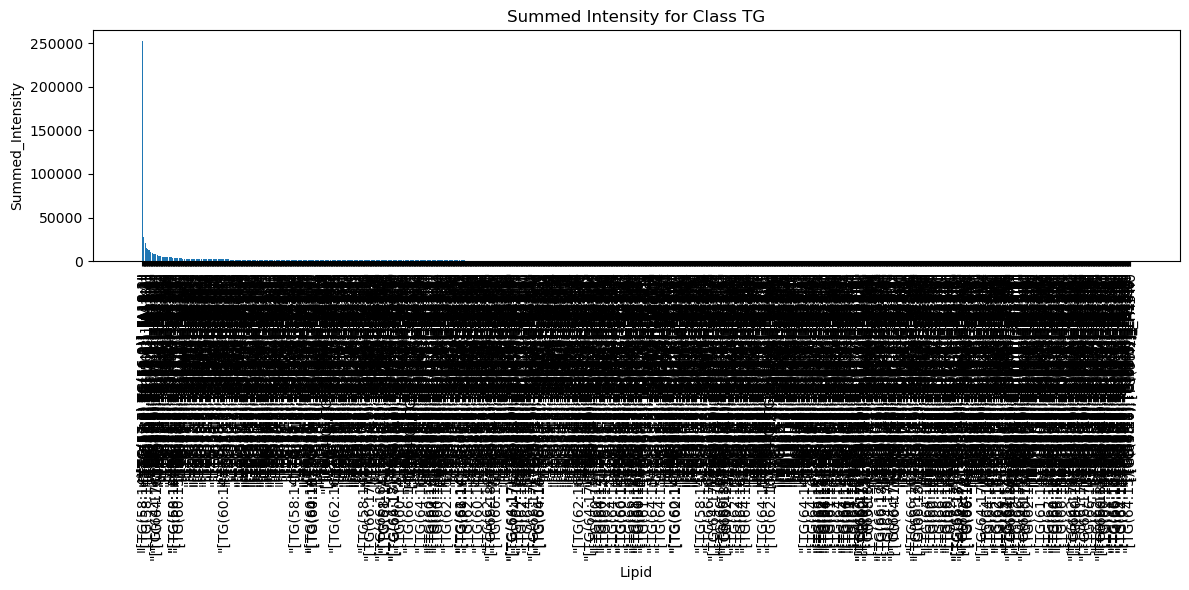

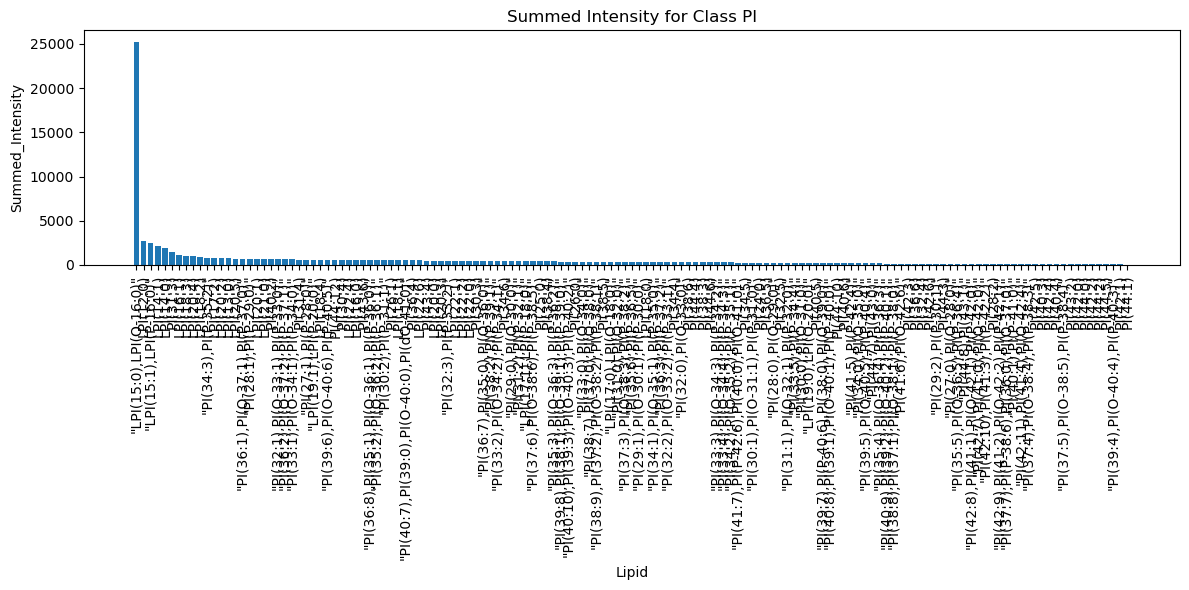

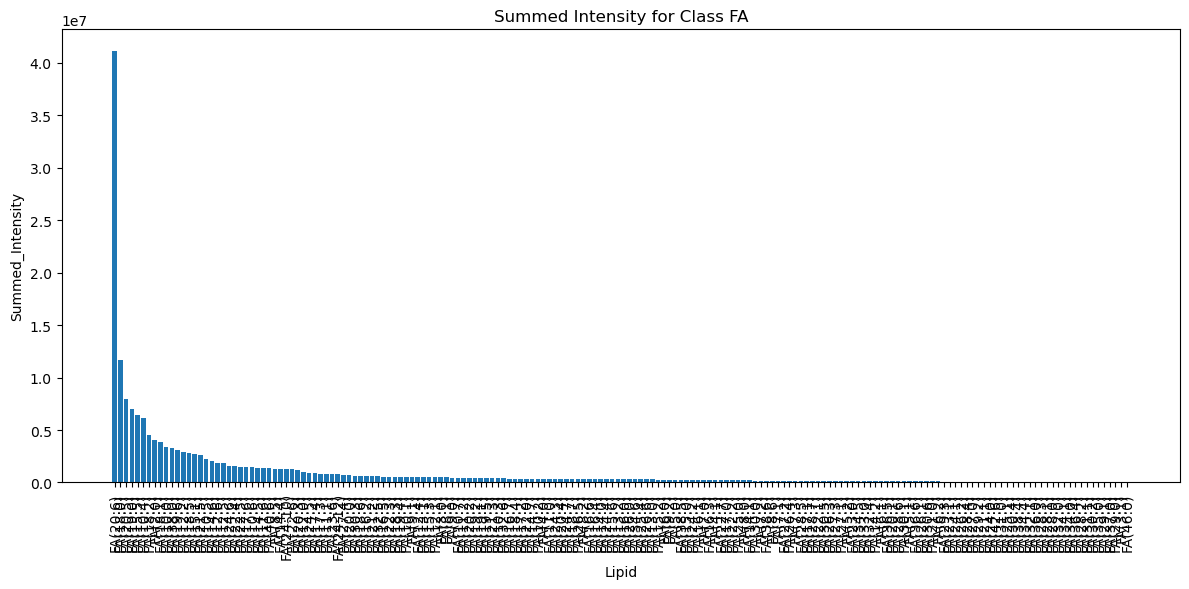

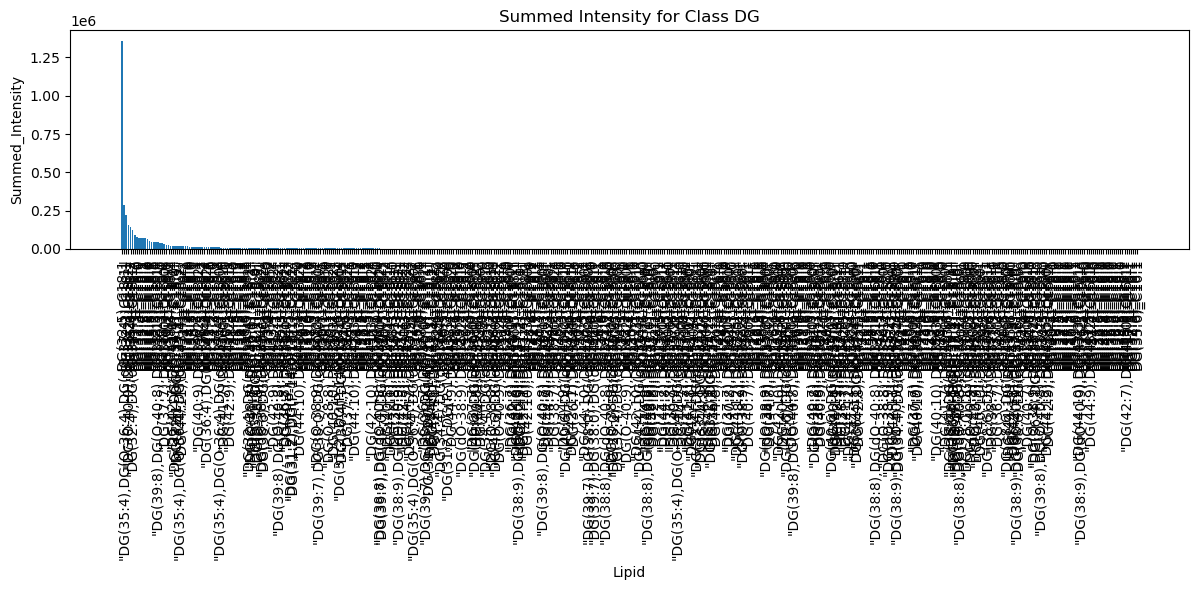

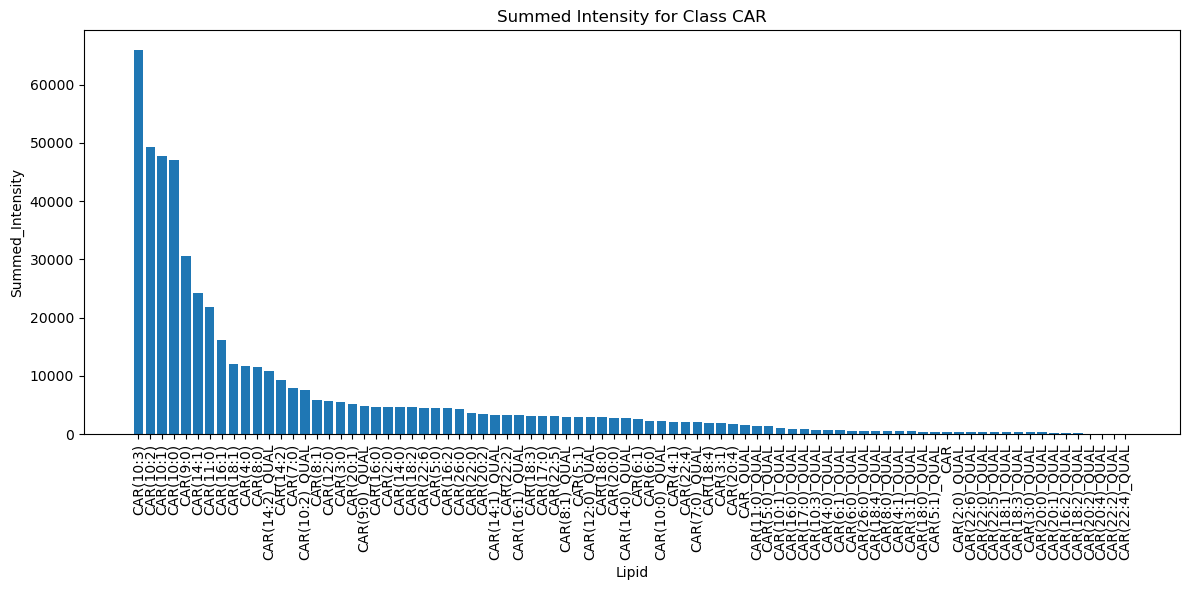

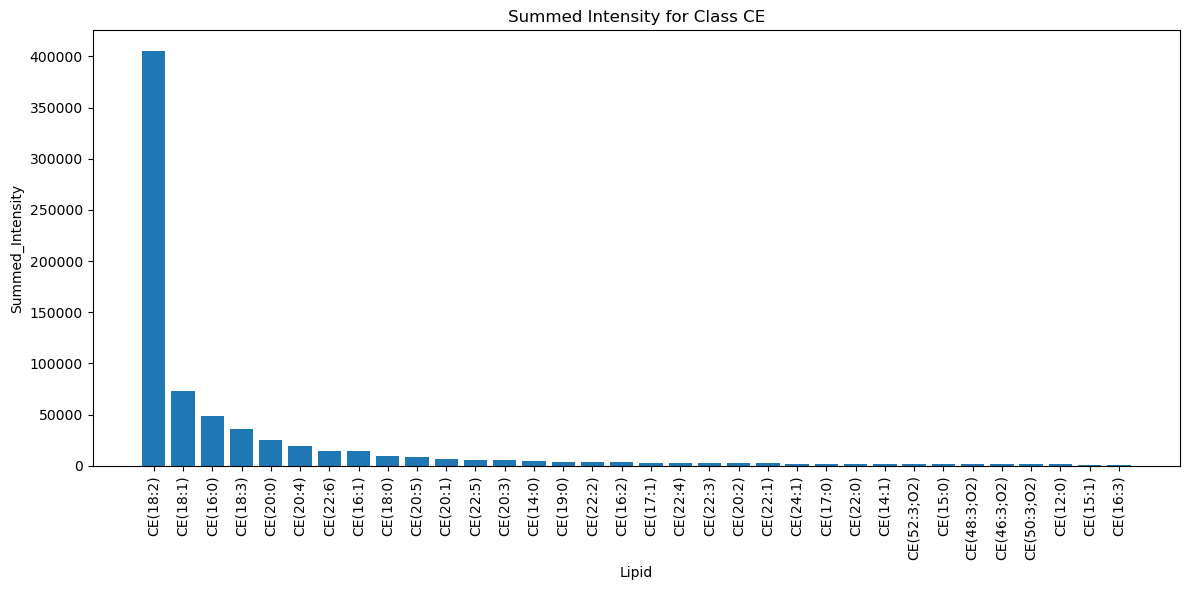

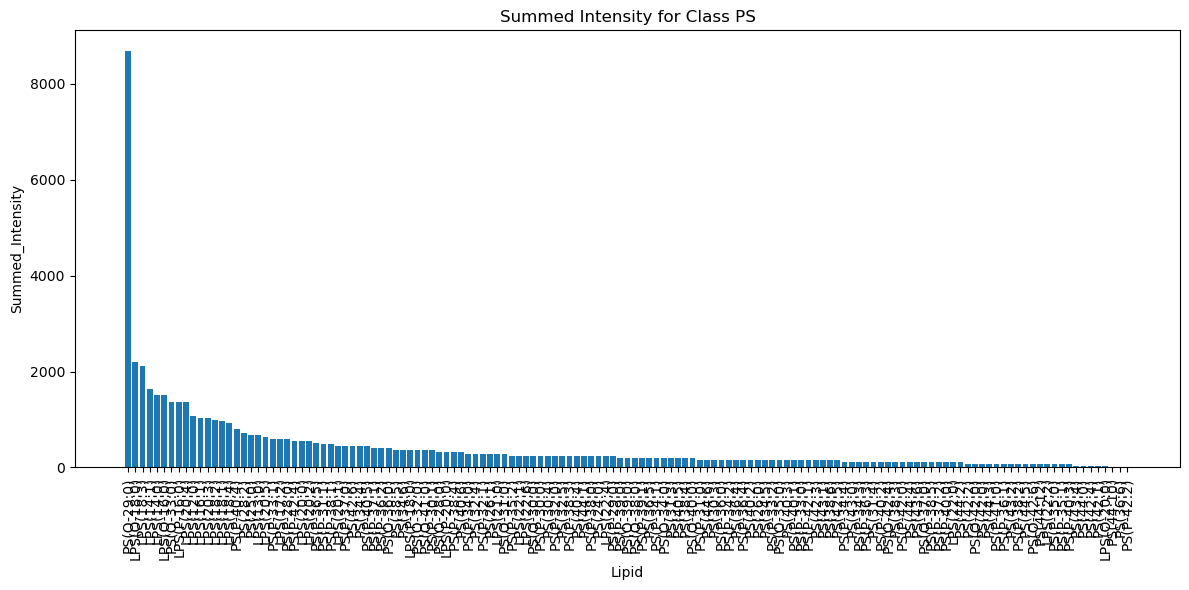

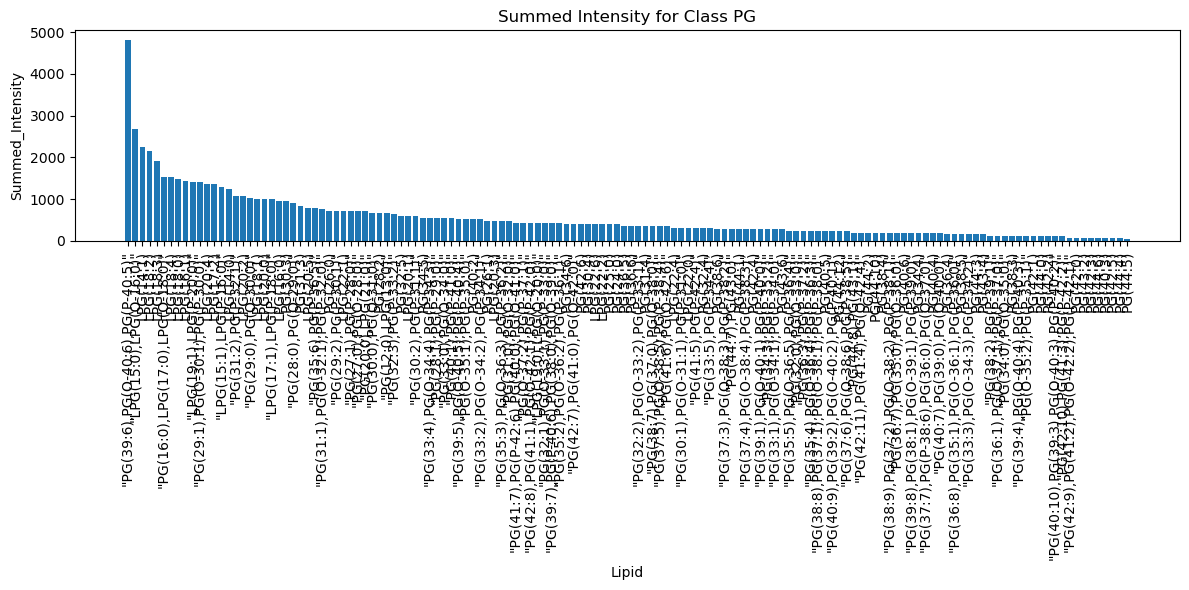

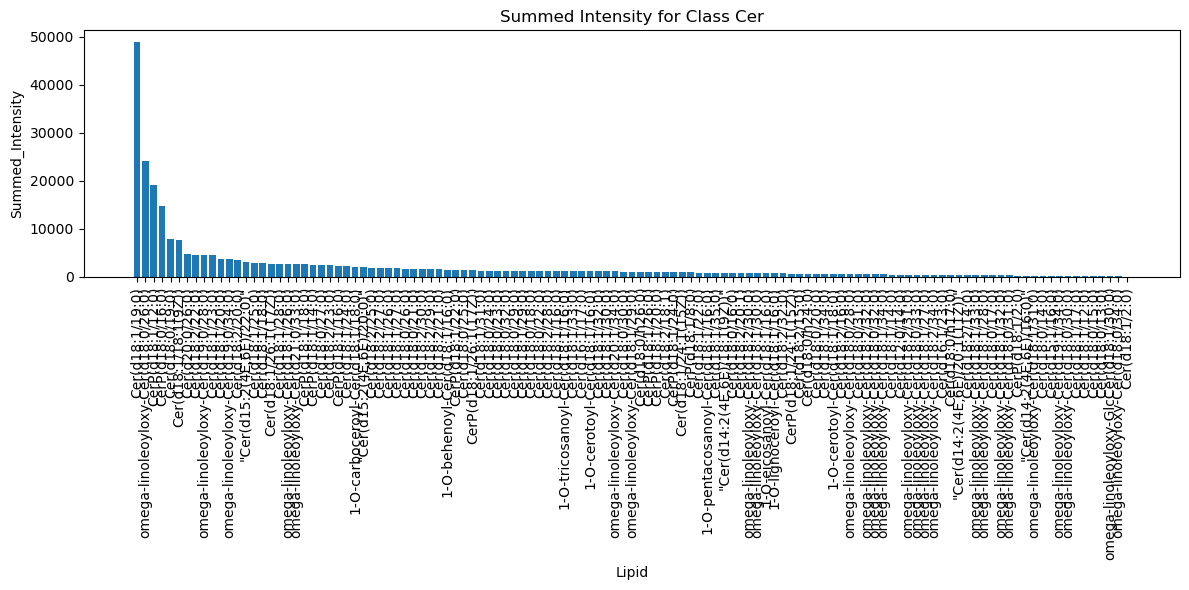

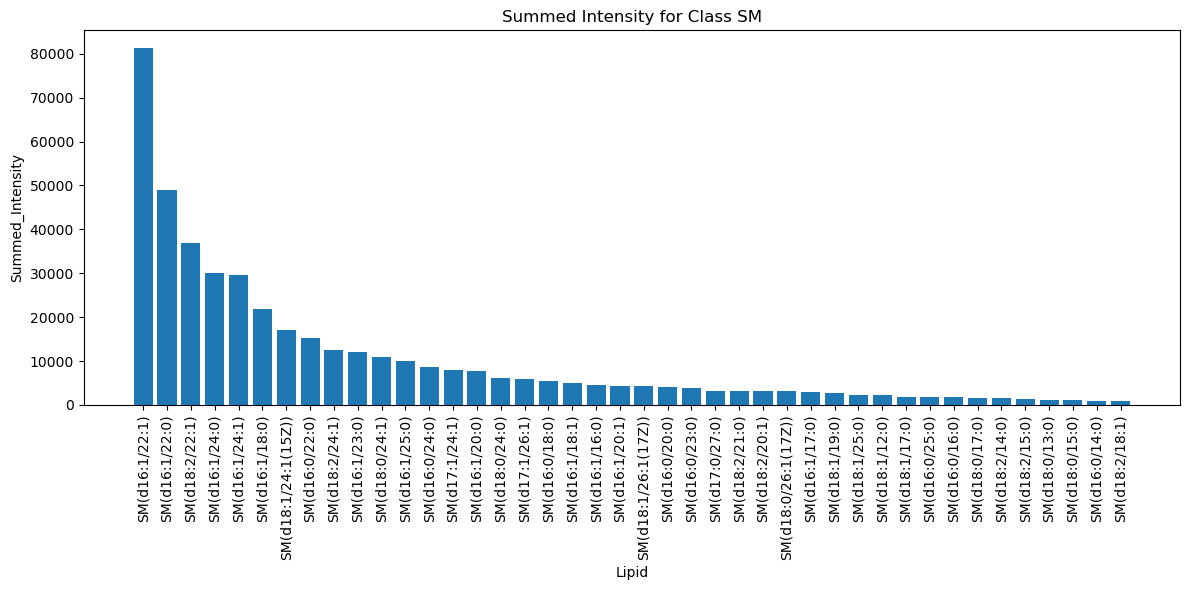

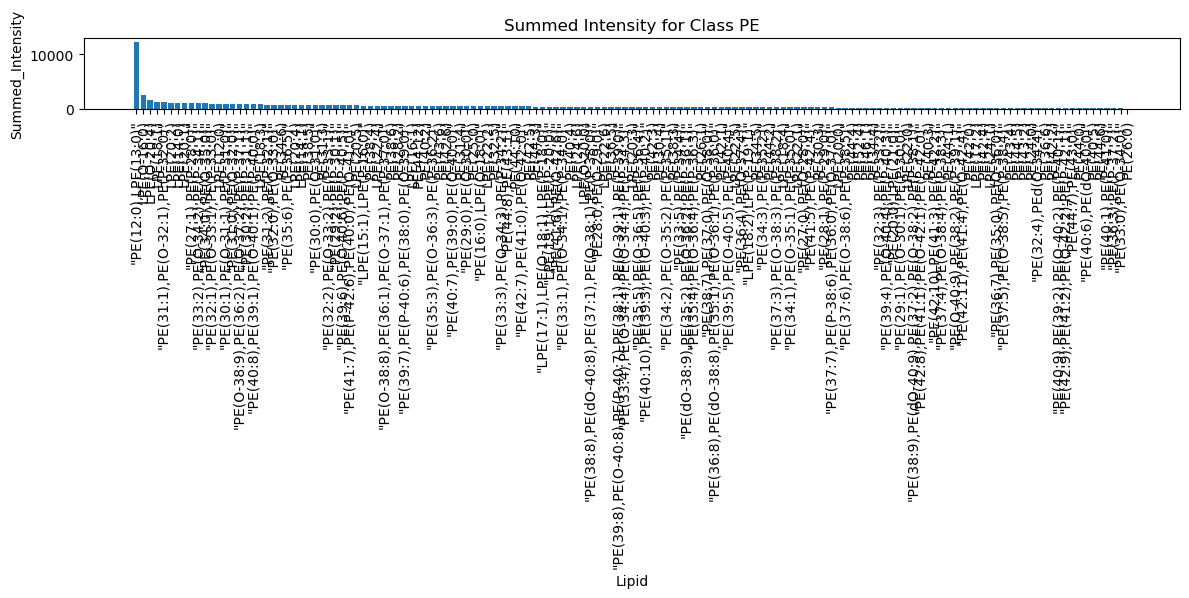

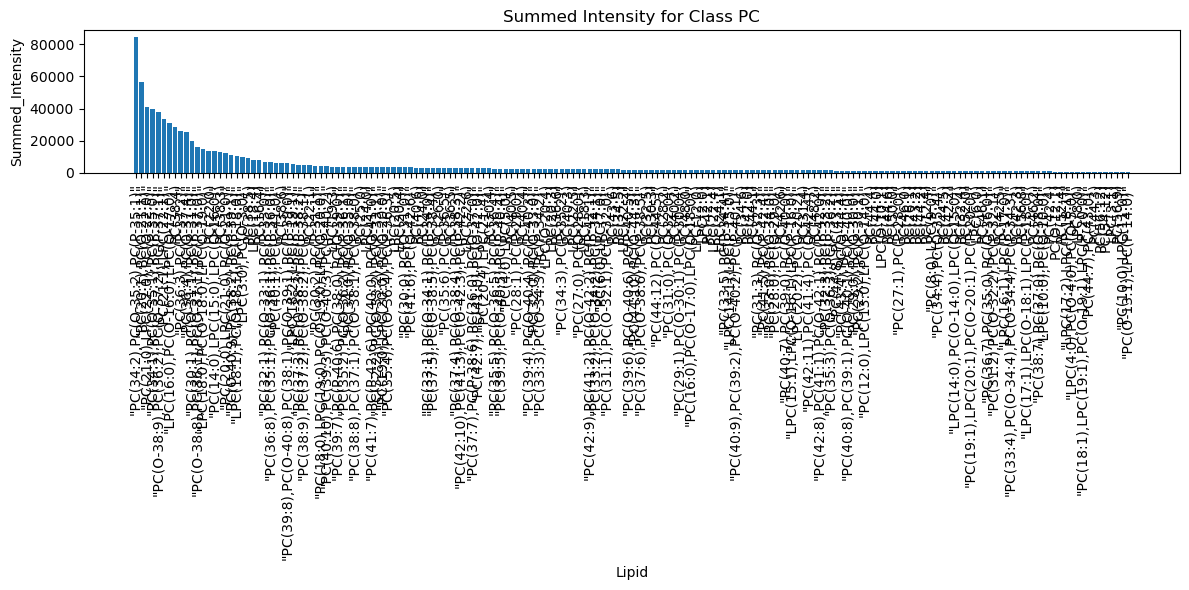

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_summed_intensity_by_class(df, top_n=None):
    classes = df['Class'].unique()
    for lipid_class in classes:
        df_class = df[df['Class'] == lipid_class]
        df_class_sorted = df_class.sort_values(by='Summed_Intensity', ascending=False)

        if top_n:
            df_class_sorted = df_class_sorted.head(top_n)

        plt.figure(figsize=(12, 6))
        plt.bar(df_class_sorted['Lipid'], df_class_sorted['Summed_Intensity'])
        plt.xticks(rotation=90)
        plt.xlabel('Lipid')
        plt.ylabel('Summed_Intensity')
        plt.title(f'Summed Intensity for Class {lipid_class}')
        plt.tight_layout()
        plt.show()

# Assuming 'chromatogram_data' is your DataFrame
plot_summed_intensity_by_class(chromatogram_data)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_summed_intensity_by_class(df, top_n=None):
    classes = df['Class'].unique()
    for lipid_class in classes:
        df_class = df[df['Class'] == lipid_class]
        df_class_sorted = df_class.sort_values(by='Summed_Intensity', ascending=False)

        if top_n:
            df_class_sorted = df_class_sorted.head(top_n)

        # Save the sorted DataFrame to a CSV file
        csv_filename = f"{lipid_class}_summed_intensity.csv"
        df_class_sorted.to_csv(csv_filename, index=False)
        print(f"Saved sorted DataFrame for class '{lipid_class}' to '{csv_filename}'")

        # Plot and save the figure
        plt.figure(figsize=(12, 6))
        plt.bar(df_class_sorted['Lipid'], df_class_sorted['Summed_Intensity'])
        plt.xticks(rotation=90)
        plt.xlabel('Lipid')
        plt.ylabel('Summed_Intensity')
        plt.title(f'Summed Intensity for Class {lipid_class}')
        plt.tight_layout()
        plot_filename = f"{lipid_class}_summed_intensity_plot.png"
        plt.savefig(plot_filename)
        plt.close()
        print(f"Saved plot for class '{lipid_class}' to '{plot_filename}'")

# Assuming 'chromatogram_data' is your DataFrame
plot_summed_intensity_by_class(chromatogram_data)


Saved sorted DataFrame for class 'TG' to 'TG_summed_intensity.csv'
Saved plot for class 'TG' to 'TG_summed_intensity_plot.png'
Saved sorted DataFrame for class 'PI' to 'PI_summed_intensity.csv'
Saved plot for class 'PI' to 'PI_summed_intensity_plot.png'
Saved sorted DataFrame for class 'FA' to 'FA_summed_intensity.csv'
Saved plot for class 'FA' to 'FA_summed_intensity_plot.png'
Saved sorted DataFrame for class 'DG' to 'DG_summed_intensity.csv'
Saved plot for class 'DG' to 'DG_summed_intensity_plot.png'
Saved sorted DataFrame for class 'CAR' to 'CAR_summed_intensity.csv'
Saved plot for class 'CAR' to 'CAR_summed_intensity_plot.png'
Saved sorted DataFrame for class 'CE' to 'CE_summed_intensity.csv'
Saved plot for class 'CE' to 'CE_summed_intensity_plot.png'
Saved sorted DataFrame for class 'PS' to 'PS_summed_intensity.csv'
Saved plot for class 'PS' to 'PS_summed_intensity_plot.png'
Saved sorted DataFrame for class 'PG' to 'PG_summed_intensity.csv'
Saved plot for class 'PG' to 'PG_summed_

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_summed_intensity_by_class(df, top_n=None):
    classes = df['Class'].unique()
    for lipid_class in classes:
        df_class = df[df['Class'] == lipid_class]
        df_class_sorted = df_class.sort_values(by='Summed_Intensity', ascending=False)

        if top_n:
            df_class_sorted = df_class_sorted.head(top_n)

        # Save the sorted DataFrame to a CSV file
        csv_filename = f"{lipid_class}_summed_intensity.csv"
        df_class_sorted.to_csv(csv_filename, index=False)
        print(f"Saved sorted DataFrame for class '{lipid_class}' to '{csv_filename}'")

        # Plot and save the figure
        plt.figure(figsize=(12, 6))
        plt.bar(df_class_sorted['Lipid'], df_class_sorted['Summed_Intensity'])
        plt.xticks(rotation=90)
        plt.xlabel('Lipid')
        plt.ylabel('Summed_Intensity')
        plt.title(f'Summed Intensity for Class {lipid_class}')
        plt.tight_layout()
        plot_filename = f"{lipid_class}_summed_intensity_plot.png"
        plt.savefig(plot_filename)
        plt.close()
        print(f"Saved plot for class '{lipid_class}' to '{plot_filename}'")

# Assuming 'chromatogram_data' is your DataFrame
plot_summed_intensity_by_class(chromatogram_data)


# Update plot with differnt columns

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_lipid_intensity(df, intensity_column, top_n=None):
    """
    Plot intensity data for each lipid class from specified column.
    
    Args:
        df: DataFrame with lipid data
        intensity_column: Column name for intensity values
        top_n: Optional limit for number of lipids to plot
    """
    classes = df['Class'].unique()
    
    for lipid_class in classes:
        df_class = df[df['Class'] == lipid_class]
        df_class_sorted = df_class.sort_values(by=intensity_column, ascending=False)
        
        if top_n:
            df_class_sorted = df_class_sorted.head(top_n)
        
        # Save sorted data
        csv_filename = f"{lipid_class}_{intensity_column}.csv"
        df_class_sorted.to_csv(csv_filename, index=False)
        
        # Create plot
        plt.figure(figsize=(12, 6))
        plt.bar(df_class_sorted['Lipid'], df_class_sorted[intensity_column])
        plt.xticks(rotation=90)
        plt.xlabel('Lipid')
        plt.ylabel(intensity_column)
        plt.title(f'{intensity_column} for Class {lipid_class}')
        plt.tight_layout()
        
        # Save plot
        plot_filename = f"{lipid_class}_{intensity_column}_plot.png"
        plt.savefig(plot_filename)
        plt.close()

# Usage example:
# plot_lipid_intensity(chromatogram_data, 'Summed_Intensity')
plot_lipid_intensity(chromatogram_data, 'Intensity_Blank_Subtracted')
plot_lipid_intensity(chromatogram_data, 'Normalized_Intensity')

In [3]:
unknown_class_data = chromatogram_data[chromatogram_data['Class'] == 'Unknown']
unknown_class_data

,Lipid,Q1,Q3,Summed_Intensity,Intensity_Blank_Subtracted,Normalized_Intensity,TIC_RSD,Class,Sample_Name,Blank_Group,Date,Sample,TIC_Summed,Filename


# Plot

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re

def sanitize_filename(name):
    """
    Replace invalid characters in filenames with underscores to ensure valid directory names.
    """
    return re.sub(r'[\\/*?:"<>|]', "_", str(name))

def plot_lipid_intensities(input_csv, output_dir, intensity_columns_mapping, chunk_size=10):
    """
    Create bar plots for lipid intensities for each unique file in the input CSV.
    Each file gets its own directory, and multiple plots are created if there are more than 'chunk_size' lipids.
    Sorting is performed based on the 'Sample_Name' using the provided intensity_columns_mapping.

    Args:
        input_csv (str): Path to the CSV file containing parsed chromatogram data.
        output_dir (str): Directory to save the plots.
        intensity_columns_mapping (dict): A mapping from 'Sample_Name' to the intensity column to sort by.
                                         Example: {'Sample': 'Normalized_Intensity', 'Blank': 'Summed_Intensity'}
        chunk_size (int): Number of lipids per plot. Default is 10.

    Returns:
        None
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Load the CSV file into a DataFrame
    df = pd.read_csv(input_csv)

    # Verify essential columns exist
    required_columns = ['Lipid', 'Filename', 'Sample_Name'] + list(intensity_columns_mapping.values())
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Input CSV is missing required columns: {', '.join(missing_columns)}")

    # Handle missing intensity values for all relevant columns
    intensity_columns = list(intensity_columns_mapping.values())
    df = df.dropna(subset=intensity_columns)

    # Group by Filename to create separate plots for each file
    grouped = df.groupby('Filename')

    for filename, group in tqdm(grouped, desc="Processing files"):
        # Sanitize filename to create valid directory names
        sanitized_filename = sanitize_filename(filename)
        # Create a directory for the current filename
        file_dir = os.path.join(output_dir, sanitized_filename)
        os.makedirs(file_dir, exist_ok=True)

        # Determine the Sample_Name for the current group
        sample_names = group['Sample_Name'].unique()
        if len(sample_names) != 1:
            print(f"Warning: Filename '{filename}' has multiple Sample_Name values: {sample_names}. Skipping.")
            continue  # Skip groups with ambiguous Sample_Name

        sample_name = sample_names[0]

        # Determine the sorting column based on Sample_Name
        if sample_name not in intensity_columns_mapping:
            print(f"Warning: Sample_Name '{sample_name}' for Filename '{filename}' is not in the intensity_columns_mapping. Skipping.")
            continue  # Skip if Sample_Name not in mapping

        sorting_column = intensity_columns_mapping[sample_name]
        y_label = sorting_column.replace('_', ' ')

        # Sort the group based on the specified sorting column (descending)
        group_sorted = group.sort_values(by=sorting_column, ascending=False)

        # Split the lipids into chunks
        lipid_chunks = [group_sorted[i:i + chunk_size] for i in range(0, len(group_sorted), chunk_size)]

        for i, chunk in enumerate(lipid_chunks, start=1):
            if chunk.empty:
                print(f"No data for {filename} in chunk {i}. Skipping plot.")
                continue

            plt.figure(figsize=(10, 6))
            plt.bar(chunk['Lipid'], chunk[sorting_column], alpha=0.7, color='blue')
            plt.title(f"Lipid {y_label} - {filename} (Chunk {i})")
            plt.xlabel('Lipid')
            plt.ylabel(y_label)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()

            # Define the plot filename
            plot_filename = f"{sanitized_filename}_chunk_{i}_{sorting_column.lower()}.png"
            plot_file = os.path.join(file_dir, plot_filename)

            # Save the plot
            plt.savefig(plot_file)
            plt.close()

            print(f"Plot saved: {plot_file}")


# rettryin plot works as summed intensity

In [25]:
def plot_lipid_intensities(input_csv, output_dir, sorting='Lipid'):
    """
    Create bar plots for lipid intensities for each unique file in the input CSV.
    Each file gets its own directory, and multiple plots are created if there are more than 10 lipids.

    Args:
        input_csv (str): Path to the CSV file containing parsed chromatogram data.
        output_dir (str): Directory to save the plots.
        sorting (str): Sorting criterion, either 'Lipid', 'Summed_Intensity', or 'Intensity'. Default is 'Lipid'.

    Returns:
        None
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Load the CSV file into a DataFrame
    df = pd.read_csv(input_csv)
    print(df)

    # Group by Filename to create separate plots for each file
    grouped = df.groupby('Filename')

    for filename, group in tqdm(grouped, desc="Processing files"):
        # Create a directory for the current filename
        file_dir = os.path.join(output_dir, filename)
        os.makedirs(file_dir, exist_ok=True)

        # Sort the group based on the specified criterion
        if sorting == 'Summed_Intensity':
            sort_column = 'Summed_Intensity'
            ascending = False
        elif sorting == 'Lipid':
            sort_column = 'Lipid'
            ascending = True
        elif sorting == 'Intensity':
            sort_column = 'Summed_Intensity'  # or another appropriate column
            ascending = False
        else:
            raise ValueError("Invalid sorting criterion. Use 'Lipid', 'Summed_Intensity', or 'Intensity'.")

        group = group.sort_values(by=sort_column, ascending=ascending)

        # Split the lipids into chunks of 10
        lipid_chunks = [group[i:i + 10] for i in range(0, len(group), 10)]

        for i, chunk in enumerate(lipid_chunks):
            plt.figure(figsize=(10, 6))
            plt.bar(chunk['Lipid'], chunk['Summed_Intensity'], alpha=0.7, color='blue')
            plt.title(f"Lipid Intensities - {filename} (Chunk {i + 1})")
            plt.xlabel('Lipid')
            plt.ylabel('Summed_Intensity')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()

            # Save the plot in the specific directory for the current filename
            plot_file = os.path.join(file_dir, f"{filename}_chunk_{i + 1}_lipid_intensities.png")
            plt.savefig(plot_file)
            plt.close()

            print(f"Plot saved: {plot_file}")


# update for normalzied ordering

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_lipid_intensities(input_csv, output_dir, sorting='Lipid', testing='off'):
    """
    Create bar plots for lipid intensities for each unique file in the input CSV.
    Each file gets its own directory, and multiple plots are created if there are more than 10 lipids.
    If 'Sample_Name' is 'Sample', use 'Normalized_Intensity' instead of 'Summed_Intensity'.
    Optionally filter data to include only Class 'FA' when testing is 'on'.
    
    Args:
        input_csv (str): Path to the CSV file containing parsed chromatogram data.
        output_dir (str): Directory to save the plots.
        sorting (str): Sorting criterion, either 'Lipid', 'Summed_Intensity', or 'Intensity'. Default is 'Lipid'.
        testing (str): If set to 'on', filters the DataFrame to include only rows where Class == 'FA'. 
                       Accepts 'on' or 'off'. Default is 'off'.
    
    Returns:
        None
    """
    # Validate the 'testing' parameter
    if testing not in ['on', 'off']:
        raise ValueError("Invalid value for 'testing'. Use 'on' or 'off'.")
    
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Load the CSV file into a DataFrame
    df = pd.read_csv(input_csv)
    print("Initial DataFrame preview:")
    print(df.head())  # Display only the first few rows for brevity

    # Validate required columns
    required_columns = ['Filename', 'Sample_Name', 'Class', 'Lipid', 'Summed_Intensity', 'Normalized_Intensity']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"The following required columns are missing from the CSV: {missing_columns}")

    # Apply testing filter if testing is 'on'
    if testing == 'on':
        original_length = len(df)
        df = df[df['Class'] == 'FA']
        filtered_length = len(df)
        print(f"Testing mode is ON: Filtered data to include only Class 'FA'.")
        print(f"Rows before filtering: {original_length}, after filtering: {filtered_length}")

        # Check if any data remains after filtering
        if filtered_length == 0:
            raise ValueError("No data found for Class 'FA' after filtering. Check your data or testing parameter.")

    # Group by Filename to create separate plots for each file
    grouped = df.groupby('Filename')

    for filename, group in tqdm(grouped, desc="Processing files"):
        # Create a directory for the current filename
        file_dir = os.path.join(output_dir, filename)
        os.makedirs(file_dir, exist_ok=True)

        # Determine if the current group should use Normalized_Intensity
        # Assuming 'Sample_Name' is consistent within each 'Filename' group
        sample_name = group['Sample_Name'].iloc[0]
        if sample_name == 'Sample':
            intensity_column = 'Normalized_Intensity'
            y_label = 'Normalized_Intensity'
            ascending_default = False  # Typically, higher normalized intensity is better
        else:
            intensity_column = 'Summed_Intensity'
            y_label = 'Summed_Intensity'
            ascending_default = False  # Typically, higher summed intensity is better

        # Sort the group based on the specified criterion
        if sorting == 'Summed_Intensity':
            sort_column = 'Summed_Intensity'
            ascending = False
        elif sorting == 'Lipid':
            sort_column = 'Lipid'
            ascending = True
        elif sorting == 'Intensity':
            # Use the appropriate intensity column based on Sample_Name
            sort_column = intensity_column
            ascending = ascending_default
        else:
            raise ValueError("Invalid sorting criterion. Use 'Lipid', 'Summed_Intensity', or 'Intensity'.")

        group_sorted = group.sort_values(by=sort_column, ascending=ascending)

        # Split the lipids into chunks of 10
        lipid_chunks = [group_sorted[i:i + 10] for i in range(0, len(group_sorted), 10)]

        for i, chunk in enumerate(lipid_chunks):
            plt.figure(figsize=(10, 6))
            plt.bar(chunk['Lipid'], chunk[intensity_column], alpha=0.7, color='blue')
            plt.title(f"Lipid Intensities - {filename} (Chunk {i + 1})")
            plt.xlabel('Lipid')
            plt.ylabel(y_label)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()

            # Save the plot in the specific directory for the current filename
            plot_file = os.path.join(file_dir, f"{filename}_chunk_{i + 1}_lipid_intensities.png")
            plt.savefig(plot_file)
            plt.close()

            print(f"Plot saved: {plot_file}")


In [6]:
# Define input CSV and output directory for plots
input_csv = 'result/parsed_chromatogram_data.csv'
output_dir = 'result/plots/'

# Generate bar plots sorted by Intensity with testing mode ON (filter Class == 'FA')
plot_lipid_intensities(input_csv, output_dir, sorting='Intensity', testing='on')


Initial DataFrame preview:
                          Lipid      Q1      Q3  Summed_Intensity  \
0  "[TG(50:9),TG(49:2)]_FA18:3"  834.76  539.46              2000   
1  "[TG(51:9),TG(50:2)]_FA18:3"  848.77  553.47              4800   
2  "[TG(52:9),TG(51:2)]_FA18:3"  862.79  567.49               800   
3  "[TG(53:9),TG(52:2)]_FA18:3"  876.80  581.50              1400   
4  "[TG(57:9),TG(56:2)]_FA18:3"  932.86  637.56              9280   

   Intensity_Blank_Subtracted  Normalized_Intensity  TIC_RSD Class  \
0                       920.0              0.028015    15.46    SM   
1                      4040.0              0.123021    15.46    SM   
2                         0.0              0.000000    15.46    SM   
3                       640.0              0.019488    15.46    SM   
4                         0.0              0.000000    15.46    SM   

      Sample_Name  Blank_Group      Date  Sample  TIC_Summed  \
0  Plasma_TG_18-3            1  20241115  Sample      169720   
1  Plasma

Processing files:   0%|          | 0/2 [00:00<?, ?it/s]

Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_1_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_2_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_3_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_4_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_5_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_6_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_7_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_8_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_9_lipid_intensities.png
Plot saved: result/plots/20241115_Pla

Processing files:  50%|█████     | 1/2 [00:01<00:01,  1.80s/it]

Plot saved: result/plots/20241115_Plasma_Blank_FFA/20241115_Plasma_Blank_FFA_chunk_18_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_1_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_2_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_3_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_4_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_5_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_6_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_7_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_8_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_9_lipid_intensities.png
Plot saved: result/plots/20241115_Pla

Processing files: 100%|██████████| 2/2 [00:03<00:00,  1.81s/it]

Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_16_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_17_lipid_intensities.png
Plot saved: result/plots/20241115_Plasma_FFA/20241115_Plasma_FFA_chunk_18_lipid_intensities.png
